# 5.1.1 事件分布与一次实现

## 学习目标与先修知识

能区分事件（event）、随机变量（random variable）、分布（distribution）和一次实现（realization）；用总概率（probability）与曲线下面积检查离散概率和连续密度，解释测量舍入。

先修：有限求和、函数和定积分（definite integral）的面积意义（第 2.2 章）；第 1.4 章的模型（model）假设。 [复习上一节](../../04-非线性动态行为/05-用%20Lyapunov%20函数分析稳定性/02-非严格衰减与不能省略的条件.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

同一培养条件下，不同细胞的活跃标签不完全相同；同一理想读数也可能被仪器读成附近的值。一次观察该怎样联系到一个描述所有可能结果的模型？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
labels=[0,1,0,0,1,0,1,0,0,0]
display(Markdown(show_table(['量','结果'],[['本次观察的活跃数',sum(labels)],['本次数量',len(labels)],['本次频率',sum(labels)/len(labels)]])))

| 量 | 结果 |
| --- | --- |
| 本次观察的活跃数 | 3 |
| 本次数量 | 10 |
| 本次频率 | 0.3 |

## 模型假设

细胞只分静息 0、活跃 1；活跃概率取 p=0.3。测量误差 E 在 [−0.2,0.2] U 上均匀，理想读数固定为 1 U。误差可以为负，表示低于理想读数。细胞标签和仪器误差是两个不同实验。

## 数学解释与推导

把一次实验所有可能结果组成样本空间（sample space）；事件是其中的一个集合。随机变量 X 把结果变成数，例如 X=1 表示活跃。分布给出各种结果的概率，而 x=0 或 1 是一次实现。

离散概率质量函数（probability mass function）写成 P(X=0)=1−p、P(X=1)=p。各项非负且相加为 1；对于不重叠事件，概率可以相加。观察到一次 1 不会把 p 改成 1；十次观察也不保证有 3 次为 1。

连续误差用概率密度（probability density） f 描述。均匀模型的支持区间宽度 0.4 U，故区间内 f(e)=1/0.4=2.5/U，区间外为零。归一化要求积分面积为 1，密度本身可以大于 1：
$$P(l\le E\le r)=\int_l^r f(e)\,de=\frac{\max(0,\min(r,0.2)-\max(l,-0.2))}{0.4}.$$
点没有宽度，所以连续模型中 P(E=0)=0；它不是一个不可能被显示的读数。若仪器四舍五入到 0.1 U，显示误差为 0.0 对应近似区间 [−0.05,0.05)，概率为 0.25。单点端点的取舍不改变连续概率。

## 核心实现

把公式中的量和顺序写成可检查的计算。

In [3]:
def uniform_probability(low, high, left, right):
    overlap = max(0.0, min(high, right)-max(low, left))
    return overlap/(high-low)

## 对照实验

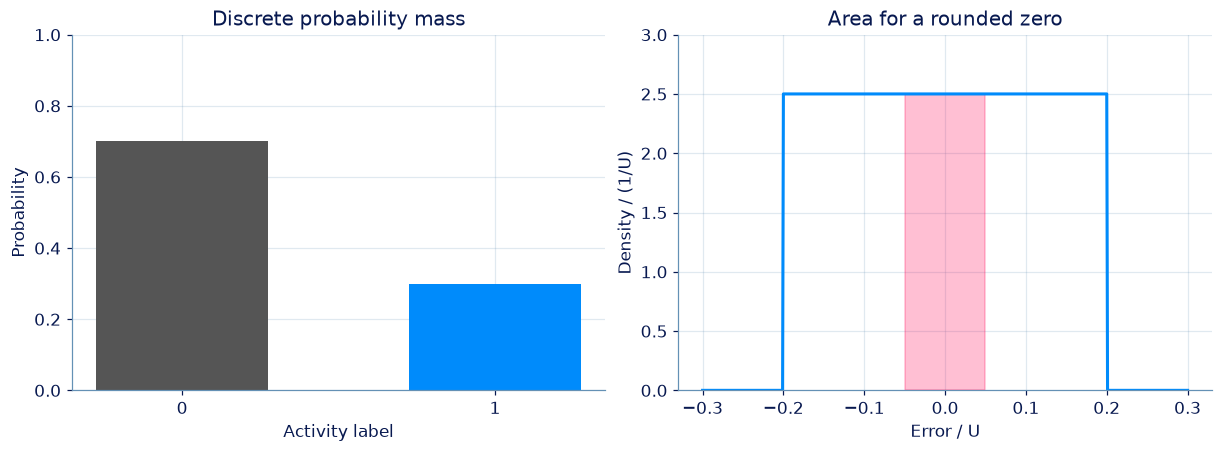

| 事件 | 概率 |
| --- | --- |
| 精确为零 | 0 |
| 显示一位小数为零 | 0.25 |
| 全部支持集 | 1 |

In [4]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].bar([0,1],[.7,.3],color=[GRAY,BLUE],width=.55)
axes[0].set(xticks=[0,1],xlabel='Activity label',ylabel='Probability',ylim=(0,1),title='Discrete probability mass')
e=np.linspace(-.3,.3,601);density=np.where(abs(e)<=.2,2.5,0)
axes[1].plot(e,density,color=BLUE)
axes[1].fill_between(e,0,density,where=(e>=-.05)&(e<=.05),color=PINK,alpha=.25)
axes[1].set(xlabel='Error / U',ylabel='Density / (1/U)',ylim=(0,3),title='Area for a rounded zero')
plt.show()
display(Markdown(show_table(['事件','概率'],[['精确为零',uniform_probability(-.2,.2,0,0)],['显示一位小数为零',uniform_probability(-.2,.2,-.05,.05)],['全部支持集',uniform_probability(-.2,.2,-1,1)]])))

## 结果解释

离散柱的高度是概率；连续曲线的高度是密度，阴影面积才是概率。本次十个标签的频率恰好为 0.3，只是给定数组（array）的结果；没有理由要求下一批也恰好相同。

### 独立核对

用等宽四分区独立检查总面积；不以某一幅图的外观代替归一化。

In [5]:
assert math.isclose(uniform_probability(-.2,.2,-.05,.05),.25)
assert uniform_probability(-.2,.2,0,0)==0
assert uniform_probability(-.2,.2,.3,.4)==0
assert math.isclose(sum(uniform_probability(-.2,.2,a,b) for a,b in [(-.2,-.1),(-.1,0),(0,.1),(.1,.2)]),1)
print('区间面积、点概率、支持集外事件和分割归一化一致。')

区间面积、点概率、支持集外事件和分割归一化一致。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/05-01-从重复实验建立概率/explore/)：改变一个条件，比较实现、分布与理论参照，再返回完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 多项选择题：事件、随机变量与一次观察

每次随机抽取一个理想细胞，X=1 表示当次处于活跃态，X=0 表示静息态。模型（model）规定 P(X=1)=0.3。哪些说法成立？

- **A.** X 是把结果映射为数的随机变量（random variable）。
- **B.** 某次观察到 1，所以模型概率（probability）必为 1。
- **C.** {X=1} 是事件（event）。
- **D.** 十次观察一定恰好有三次为 1。

[作答：事件、随机变量与一次观察](http://127.0.0.1:8000/chapters/05-01-%E4%BB%8E%E9%87%8D%E5%A4%8D%E5%AE%9E%E9%AA%8C%E5%BB%BA%E7%AB%8B%E6%A6%82%E7%8E%87/practice/?question=p05-event-variable)

### 第 2 题 · Python 计算题：密度曲线下的概率

测量误差在 [low,high] 上均匀分布（distribution）。求它落入闭区间 [left,right] 的概率（probability）；区间可以部分位于支持集之外。

**函数与代码模板**

```python
def solve(
    low: float,
    high: float,
    left: float,
    right: float,
) -> float:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `low` | `float` | 均匀分布的左端点。 | U |
| `high` | `float` | 均匀分布的右端点。 | U |
| `left` | `float` | 查询区间左端点。 | U |
| `right` | `float` | 查询区间右端点。 | U |

**返回值**

直接返回 probability（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `probability` | `float` | 误差位于查询区间的概率。 | 1 |

**计算规则**

取两区间重叠长度，除以 high−low；没有重叠或 left=right 时返回 0。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- −10≤low<high≤10，high−low≥0.01；−20≤left≤right≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| low | 均匀分布的左端点。 | -0.2 | U |
| high | 均匀分布的右端点。 | 0.2 | U |
| left | 查询区间左端点。 | 0 | U |
| right | 查询区间右端点。 | 0.1 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
low = -0.2
high = 0.2
left = 0
right = 0.1

result = solve(low, high, left, right)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| probability | 误差位于查询区间的概率。 | 0.25 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 0.25
```

**样例解释**

支持区间长 0.4 U，重叠长 0.1 U，概率为 0.25。密度为 2.5/U，其值大于 1 并不违反概率约束。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：密度曲线下的概率](http://127.0.0.1:8000/chapters/05-01-%E4%BB%8E%E9%87%8D%E5%A4%8D%E5%AE%9E%E9%AA%8C%E5%BB%BA%E7%AB%8B%E6%A6%82%E7%8E%87/practice/?question=p05-uniform-area)

### 第 3 题 · 多项选择题：连续测量的一个精确点

误差 E 在 [−0.2,0.2] U 上连续均匀分布（distribution）。哪些正确？

- **A.** P(−0.1≤E≤0.1)=0.5。
- **B.** 连续模型（model）中精确点的概率（probability）为零，因此仪器绝不可能显示 0.0。
- **C.** 密度为 2.5/U。
- **D.** P(E=0)=2.5。

[作答：连续测量的一个精确点](http://127.0.0.1:8000/chapters/05-01-%E4%BB%8E%E9%87%8D%E5%A4%8D%E5%AE%9E%E9%AA%8C%E5%BB%BA%E7%AB%8B%E6%A6%82%E7%8E%87/practice/?question=p05-density-point)

### 第 4 题 · 单项选择题：补齐细胞状态的概率

静息、活跃、恢复三种状态（state）互斥且穷尽，前两者概率（probability）是 0.5、0.3。恢复态概率是多少？

- **A.** 无法知道，因为所有概率都需模拟。
- **B.** 0.8。
- **C.** 0.2。
- **D.** 0.15。

[作答：补齐细胞状态的概率](http://127.0.0.1:8000/chapters/05-01-%E4%BB%8E%E9%87%8D%E5%A4%8D%E5%AE%9E%E9%AA%8C%E5%BB%BA%E7%AB%8B%E6%A6%82%E7%8E%87/practice/?question=p05-normalization)

**进一步阅读**

[MIT 6.041 讲义](https://ocw.mit.edu/courses/6-041-probabilistic-systems-analysis-and-applied-probability-fall-2010/pages/lecture-notes/)：第 1、5、8 讲：概率模型、随机变量、连续密度。